Task 1a: Data Loading and Cleaning

First 5 rows:
         Date        System Incident_Type  Count
0  2024-04-12   FinanceDB03       Malware      4
1  2025-03-11  AuthServer01       Malware      2
2  2024-09-27  AuthServer03      Priv Esc      3
3  2024-04-16   PaymentGW02  Failed Login      1
4  2024-03-12  AuthServer03      Priv Esc      1

Shape of DataFrame: (400, 4)

Date column type: datetime64[ns]

Missing values before handling:
Date              0
System           10
Incident_Type    10
Count             0
dtype: int64

Missing values after handling:
Date             0
System           0
Incident_Type    0
Count            0
dtype: int64

Unique incident types:
['MALWARE' 'PRIV ESC' 'FAILED LOGIN' 'DATA LEAK' 'PHISHING' 'SPAM' 'DDOS']

Task 1b: Data Visualisation

Total incidents per type:
Incident_Type
DATA LEAK       148
PRIV ESC        147
FAILED LOGIN    137
SPAM            128
MALWARE         124
DDOS            122
PHISHING        116
Name: Count, dtype: int64


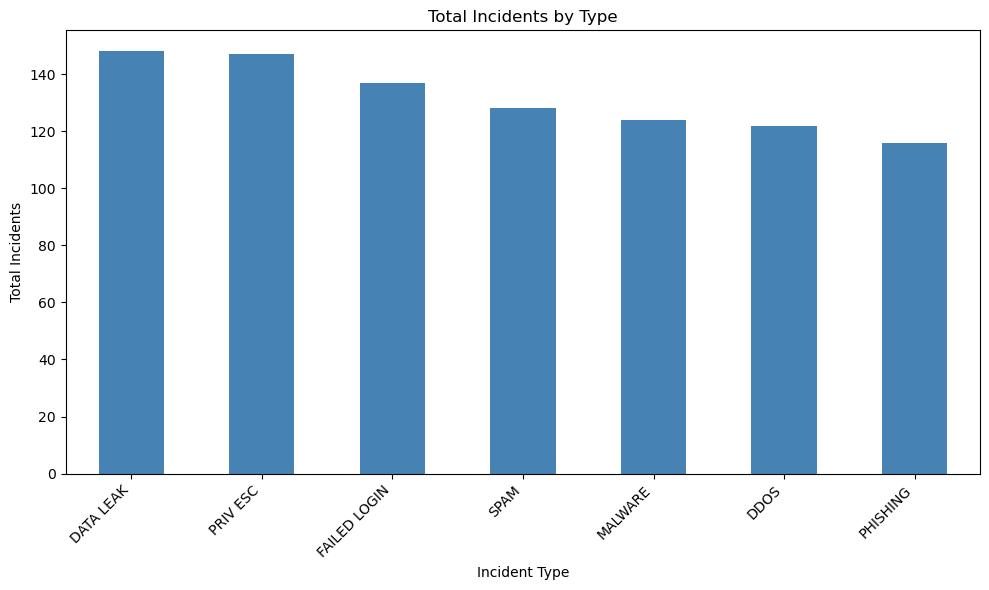


[1b-2] Monthly totals for 2025 (YYYY-MM -> total):
Date
2025-01    47
2025-02    41
2025-03    23
2025-04    64
2025-05    46
2025-06    20
2025-07    50
2025-08    24
2025-09    32
2025-10    44
2025-11    51
2025-12    37
Name: Count, dtype: int64


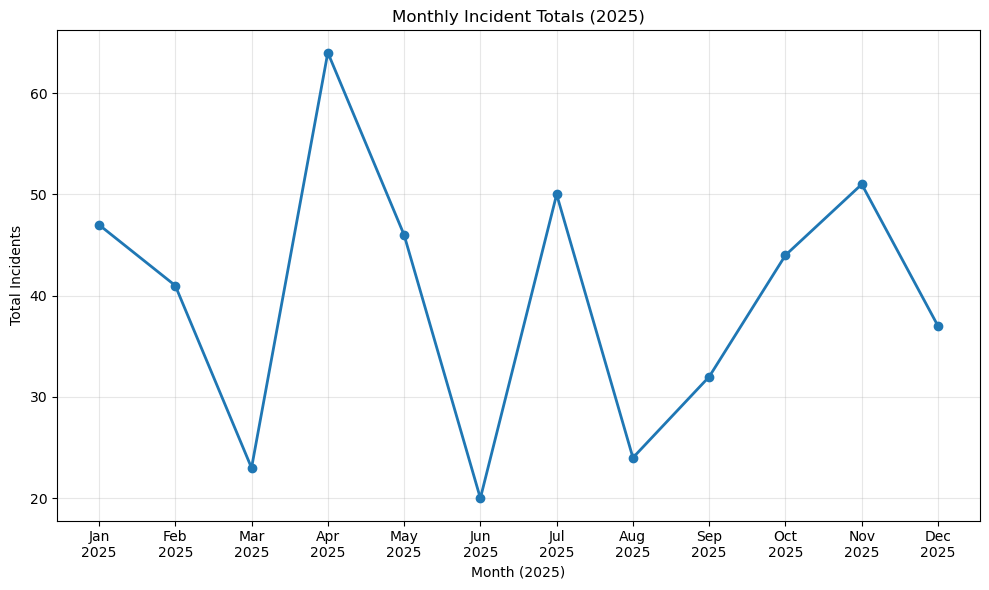


Task 2a: Database Creation and Data Insertion

Number of rows inserted: 379

Task 2b: Querying the Database

[2b-1] Total incidents in 2025: 475

[2b-2] Top 3 systems by incidents in 2025:
- PaymentGW02: 113
- AuthServer03: 94
- FinanceDB03: 93

Task 2c: Exporting Results

[2c] Top 3 systems DataFrame (to be saved to top3_systems.csv):
     System  total
0  PaymentGW02   113
1  AuthServer03  94
2  FinanceDB03   93


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sqlite3
from datetime import datetime, timedelta

np.random.seed(42)
###############################################################
dates = pd.date_range(start='2024-01-01', end='2025-12-31', freq='D')
systems = ['AuthServer01', 'AuthServer03', 'FinanceDB03', 'WebApp05', 'PaymentGW02']
incident_types = ['Failed Login', 'DDoS', 'Malware', 'Phishing', 'Spam', 'Data Leak', 'Priv Esc']

data = {
    'Date': np.random.choice(dates, 400),
    'System': np.random.choice(systems, 400),
    'Incident_Type': np.random.choice(incident_types, 400),
    'Count': np.random.randint(1, 5, 400)
}

df = pd.DataFrame(data)

missing_indices = np.random.choice(df.index, 20, replace=False)
df.loc[missing_indices[:10], 'System'] = np.nan
df.loc[missing_indices[10:], 'Incident_Type'] = np.nan

df.to_csv('cyber_incidents.csv', index=False)

print("Task 1a: Data Loading and Cleaning")
print("="*50)
#####################################################################
df = pd.read_csv('cyber_incidents.csv')
print("\nFirst 5 rows:")
print(df.head())
print(f"\nShape of DataFrame: {df.shape}")

df['Date'] = pd.to_datetime(df['Date'])
print(f"\nDate column type: {df['Date'].dtype}")

print(f"\nMissing values before handling:")
print(df.isnull().sum())

df = df.dropna()

print(f"\nMissing values after handling:")
print(df.isnull().sum())

########################
'''
print(f"\nMissing values before handling:")
print(df.isnull().sum())

df['System'] = df['System'].fillna('Unknown')
df['Incident_Type'] = df['Incident_Type'].fillna('Unknown')
df['Count'] = df['Count'].fillna(0)

print(f"\nMissing values after handling:")
print(df.isnull().sum())
'''
#########################

df['Incident_Type'] = df['Incident_Type'].str.upper().str.strip()
print("\nUnique incident types:")
print(df['Incident_Type'].unique())

print("\n" + "="*50)
print("Task 1b: Data Visualisation")
print("="*50)

incidents_per_type = df.groupby('Incident_Type')['Count'].sum().sort_values(ascending=False)
print("\nTotal incidents per type:")
print(incidents_per_type)

plt.figure(figsize=(10, 6))
incidents_per_type.plot(kind='bar', color='steelblue')
plt.title('Total Incidents by Type')
plt.xlabel('Incident Type')
plt.ylabel('Total Incidents')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

df_2025 = df[df['Date'].dt.year == 2025].copy()
df_2025['YearMonth'] = df_2025['Date'].dt.to_period('M')
monthly_totals_2025 = df_2025.groupby('YearMonth')['Count'].sum()

print("\n[1b-2] Monthly totals for 2025 (YYYY-MM -> total):")
print("Date")
for period, count in monthly_totals_2025.items():
    print(f"{period}    {count}")
print(f"Name: Count, dtype: {monthly_totals_2025.dtype}")

month_labels = [period.strftime('%b\n%Y') for period in monthly_totals_2025.index]
plt.figure(figsize=(10, 6))
plt.plot(range(len(monthly_totals_2025)), monthly_totals_2025.values, marker='o', linewidth=2, markersize=6)
plt.title('Monthly Incident Totals (2025)')
plt.xlabel('Month (2025)')
plt.ylabel('Total Incidents')
plt.xticks(range(len(monthly_totals_2025)), [period.strftime('%b\n2025') for period in monthly_totals_2025.index])
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n" + "="*50)
print("Task 2a: Database Creation and Data Insertion")
print("="*50)

conn = sqlite3.connect('IncidentsDB.db')
cursor = conn.cursor()

cursor.execute('DROP TABLE IF EXISTS Incidents')

cursor.execute('''
CREATE TABLE Incidents (
    Date TEXT,
    System TEXT,
    Incident_Type TEXT,
    Count INTEGER,
    UNIQUE(Date, System, Incident_Type)
)
''')

df_to_insert = df.copy()
df_to_insert['Date'] = df_to_insert['Date'].dt.strftime('%Y-%m-%d')

inserted_count = 0
for _, row in df_to_insert.iterrows():
    try:
        cursor.execute('''
        INSERT INTO Incidents (Date, System, Incident_Type, Count)
        VALUES (?, ?, ?, ?)
        ''', (row['Date'], row['System'], row['Incident_Type'], row['Count']))
        inserted_count += 1
    except sqlite3.IntegrityError:
        pass

conn.commit()
print(f"\nNumber of rows inserted: {inserted_count}")

print("\n" + "="*50)
print("Task 2b: Querying the Database")
print("="*50)

query_2025 = '''
SELECT SUM(Count) as total
FROM Incidents
WHERE Date LIKE '2025%'
'''
cursor.execute(query_2025)
total_2025 = cursor.fetchone()[0]
print(f"\n[2b-1] Total incidents in 2025: {total_2025}")

query_top3 = '''
SELECT System, SUM(Count) as total
FROM Incidents
WHERE Date LIKE '2025%'
GROUP BY System
ORDER BY total DESC
LIMIT 3
'''
top3_systems = pd.read_sql_query(query_top3, conn)
print("\n[2b-2] Top 3 systems by incidents in 2025:")
for idx, row in top3_systems.iterrows():
    print(f"- {row['System']}: {row['total']}")

print("\n" + "="*50)
print("Task 2c: Exporting Results")
print("="*50)

print("\n[2c] Top 3 systems DataFrame (to be saved to top3_systems.csv):")
print(f"     System  total")
for idx, row in top3_systems.iterrows():
    print(f"{idx}  {row['System']:12s}  {row['total']}")

top3_systems.to_csv('top3_systems.csv', index=False)

conn.close()

Python Task 1: Data Analysis and Visualisation

Task 1a: Data Loading and Cleaning

First 5 rows:
         Date      Corridor Delay_Type  Minutes_Delayed
0  2024-04-12    South Loop    weather             47.0
1  2025-03-11    South Loop     signal             74.0
2  2024-09-27     East Line   accident             43.0
3  2024-04-16  City Express     signal             60.0
4  2024-03-12  City Express   accident             67.0

DataFrame shape: (500, 4)

Column types after conversion:
Date               datetime64[ns]
Corridor                   object
Delay_Type                 object
Minutes_Delayed           float64
dtype: object

Missing values before handling:
Date                0
Corridor           10
Delay_Type         10
Minutes_Delayed    10
dtype: int64

Missing values after handling:
Date               0
Corridor           0
Delay_Type         0
Minutes_Delayed    0
dtype: int64

Unique standardized Delay_Type values:
['WEATHER' 'SIGNAL' 'ACCIDENT' 'UNKNOWN' 'MAINTENANCE'

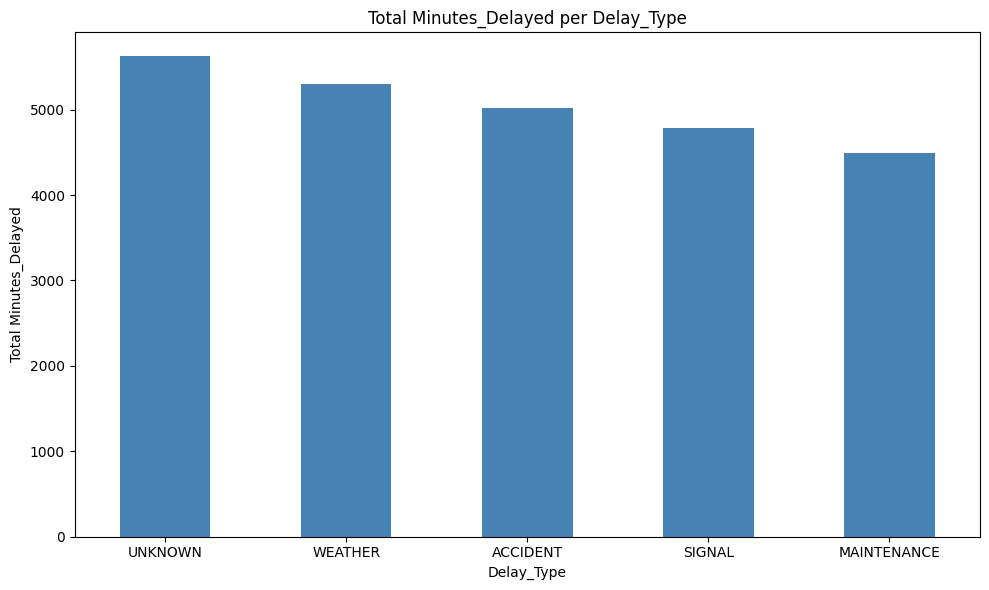


Total Minutes_Delayed per month in 2025:
Month 01: 1310.0
Month 02: 992.0
Month 03: 732.0
Month 04: 1298.0
Month 05: 1421.0
Month 06: 506.0
Month 07: 1416.0
Month 08: 698.0
Month 09: 851.0
Month 10: 1348.0
Month 11: 1466.0
Month 12: 863.0


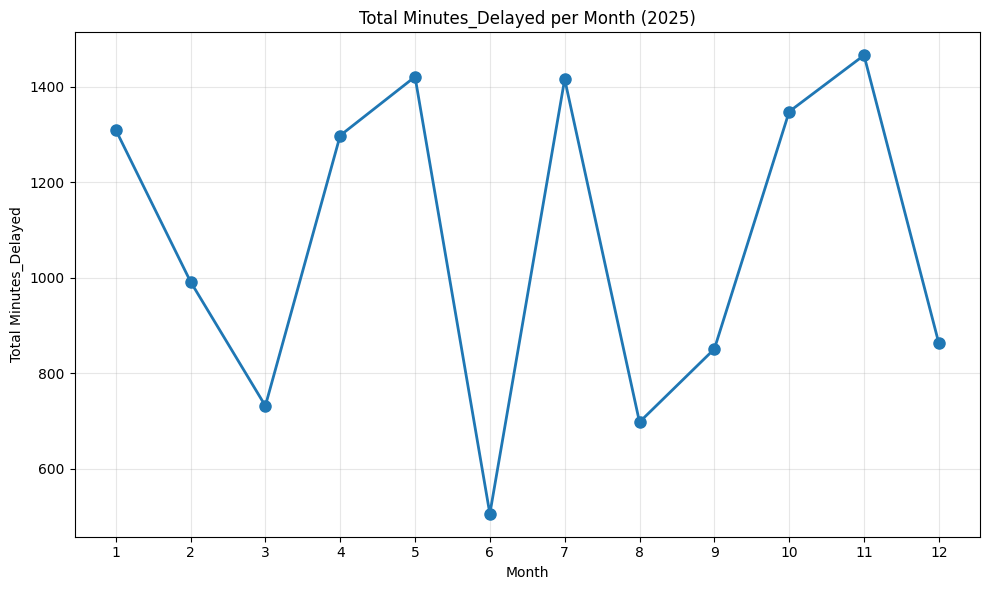


Python Task 2: Database Management and File Handling [15 Marks]

Task 2a: Database Creation and Data Insertion

Task 2a: Database Creation and Data Insertion

[2a-1] Created/connected to database: TransitDB
[2a-2] Ensured table 'Delays' exists with UNIQUE(Date, Corridor, Delay_Type).
[2a-3] Rows inserted into Delays (ignoring duplicates): 495

Task 2b: Querying the Database

Total Minutes_Delayed recorded in 2025: 12901

Top 5 corridors by total Minutes_Delayed in 2025:
1. South Loop: 2836
2. East Line: 2397
3. River Loop: 2374
4. City Express: 1718
5. West Route: 1639

Total Minutes_Delayed per month in 2025:
Month 01: 1310
Month 02: 992
Month 03: 732
Month 04: 1298
Month 05: 1421
Month 06: 506
Month 07: 1416
Month 08: 698
Month 09: 851
Month 10: 1348
Month 11: 1466
Month 12: 863

Task 2c: Exporting Results

Task 2c: Exporting Results

Top 5 corridors DataFrame (to be saved):
       Corridor  TotalMinutes
0  South Loop            2836
1  East Line             2397
2  River Loop      

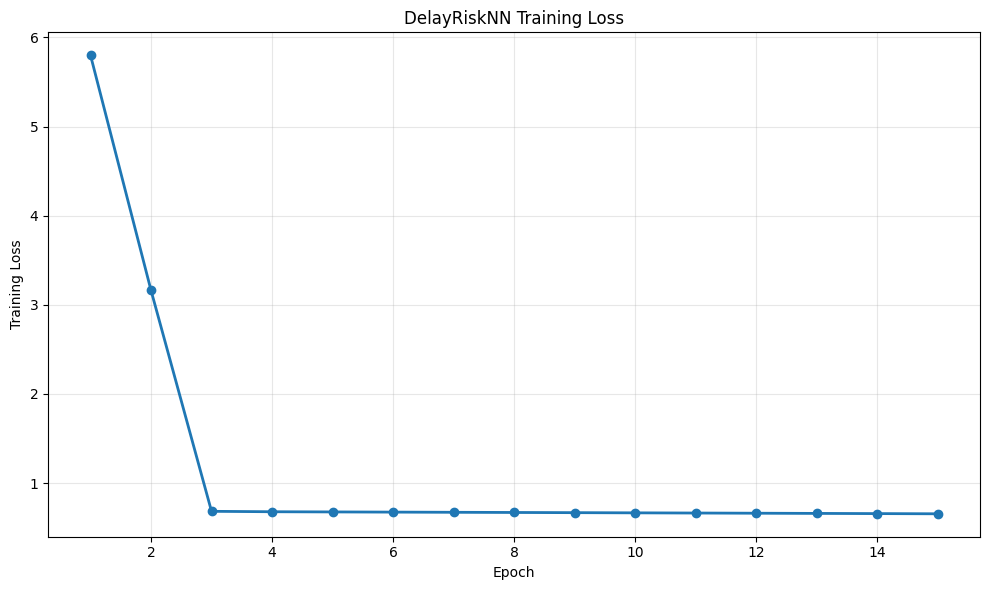


All tasks completed successfully!


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sqlite3

from datetime import datetime, timedelta

np.random.seed(42)

dates = pd.date_range(start='2024-01-01', end='2025-12-31', freq='D')
corridors = ['South Loop', 'North Loop', 'City Express', 'River Loop', 'East Line', 'West Route']
delay_types = ['weather', 'signal', 'accident', 'maintenance', 'unknown']

data = {
    'Date': np.random.choice(dates, 500),
    'Corridor': np.random.choice(corridors, 500),
    'Delay_Type': np.random.choice(delay_types, 500),
    'Minutes_Delayed': np.random.randint(5, 100, 500)
}

df = pd.DataFrame(data)

missing_indices = np.random.choice(df.index, 30, replace=False)
df.loc[missing_indices[:10], 'Corridor'] = np.nan
df.loc[missing_indices[10:20], 'Delay_Type'] = np.nan
df.loc[missing_indices[20:], 'Minutes_Delayed'] = np.nan

df.to_csv('transport_delays.csv', index=False)

print("Python Task 1: Data Analysis and Visualisation")
print("="*60)
print("\nTask 1a: Data Loading and Cleaning")
print("="*60)

df = pd.read_csv('transport_delays.csv')
print("\nFirst 5 rows:")
print(df.head())
print(f"\nDataFrame shape: {df.shape}")

df['Date'] = pd.to_datetime(df['Date'])
print(f"\nColumn types after conversion:")
print(df.dtypes)

print(f"\nMissing values before handling:")
print(df.isnull().sum())

df['Corridor'] = df['Corridor'].fillna('UNKNOWN')
df['Delay_Type'] = df['Delay_Type'].fillna('UNKNOWN')
df['Minutes_Delayed'] = df['Minutes_Delayed'].fillna(0)

print(f"\nMissing values after handling:")
print(df.isnull().sum())

df['Delay_Type'] = df['Delay_Type'].str.upper().str.strip()
print("\nUnique standardized Delay_Type values:")
print(df['Delay_Type'].unique())

print("\n" + "="*60)
print("Task 1b: Data Visualisation")
print("="*60)

delay_per_type = df.groupby('Delay_Type')['Minutes_Delayed'].sum().sort_values(ascending=False)
print("\nTask 1b: Data Visualisation")
print("="*60)
print("\nTotal Minutes_Delayed per Delay_Type:")
print(delay_per_type.to_string())
print(f"Name: Minutes_Delayed, dtype: {delay_per_type.dtype}")

plt.figure(figsize=(10, 6))
delay_per_type.plot(kind='bar', color='steelblue')
plt.title('Total Minutes_Delayed per Delay_Type')
plt.xlabel('Delay_Type')
plt.ylabel('Total Minutes_Delayed')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

df_2025 = df[df['Date'].dt.year == 2025].copy()
df_2025['Month'] = df_2025['Date'].dt.month
monthly_totals_2025 = df_2025.groupby('Month')['Minutes_Delayed'].sum()

print("\nTotal Minutes_Delayed per month in 2025:")
for month, total in monthly_totals_2025.items():
    print(f"Month {month:02d}: {total}")

plt.figure(figsize=(10, 6))
plt.plot(monthly_totals_2025.index, monthly_totals_2025.values, marker='o', linewidth=2, markersize=8)
plt.title('Total Minutes_Delayed per Month (2025)')
plt.xlabel('Month')
plt.ylabel('Total Minutes_Delayed')
plt.xticks(range(1, 13))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("Python Task 2: Database Management and File Handling [15 Marks]")
print("="*60)
print("\nTask 2a: Database Creation and Data Insertion")
print("="*60)

conn = sqlite3.connect('TransitDB.db')
cursor = conn.cursor()

cursor.execute('DROP TABLE IF EXISTS Delays')

cursor.execute('''
CREATE TABLE Delays (
    Date TEXT,
    Corridor TEXT,
    Delay_Type TEXT,
    Minutes_Delayed INTEGER,
    UNIQUE(Date, Corridor, Delay_Type)
)
''')

print("\nTask 2a: Database Creation and Data Insertion")
print("="*60)
print("\n[2a-1] Created/connected to database: TransitDB")
print("[2a-2] Ensured table 'Delays' exists with UNIQUE(Date, Corridor, Delay_Type).")

df_to_insert = df.copy()
df_to_insert['Date'] = df_to_insert['Date'].dt.strftime('%Y-%m-%d')

df_aggregated = df_to_insert.groupby(['Date', 'Corridor', 'Delay_Type'], as_index=False)['Minutes_Delayed'].sum()

inserted_count = 0
for _, row in df_aggregated.iterrows():
    try:
        cursor.execute('''
        INSERT INTO Delays (Date, Corridor, Delay_Type, Minutes_Delayed)
        VALUES (?, ?, ?, ?)
        ''', (row['Date'], row['Corridor'], row['Delay_Type'], int(row['Minutes_Delayed'])))
        inserted_count += 1
    except sqlite3.IntegrityError:
        pass

conn.commit()
print(f"[2a-3] Rows inserted into Delays (ignoring duplicates): {inserted_count}")

print("\n" + "="*60)
print("Task 2b: Querying the Database")
print("="*60)

query_total_2025 = '''
SELECT SUM(Minutes_Delayed) as total
FROM Delays
WHERE Date LIKE '2025%'
'''
cursor.execute(query_total_2025)
total_2025 = cursor.fetchone()[0]
print(f"\nTotal Minutes_Delayed recorded in 2025: {total_2025}")

query_top5 = '''
SELECT Corridor, SUM(Minutes_Delayed) as TotalMinutes
FROM Delays
WHERE Date LIKE '2025%'
GROUP BY Corridor
ORDER BY TotalMinutes DESC
LIMIT 5
'''
top5_corridors = pd.read_sql_query(query_top5, conn)
print("\nTop 5 corridors by total Minutes_Delayed in 2025:")
for idx, row in top5_corridors.iterrows():
    print(f"{idx+1}. {row['Corridor']}: {row['TotalMinutes']}")

query_monthly_2025 = '''
SELECT strftime('%m', Date) as Month, SUM(Minutes_Delayed) as Total
FROM Delays
WHERE Date LIKE '2025%'
GROUP BY Month
ORDER BY Month
'''
monthly_2025_db = pd.read_sql_query(query_monthly_2025, conn)
print("\nTotal Minutes_Delayed per month in 2025:")
for _, row in monthly_2025_db.iterrows():
    print(f"Month {row['Month']}: {row['Total']}")

print("\n" + "="*60)
print("Task 2c: Exporting Results")
print("="*60)

print("\nTask 2c: Exporting Results")
print("="*60)
print("\nTop 5 corridors DataFrame (to be saved):")
print(f"       Corridor  TotalMinutes")
for idx, row in top5_corridors.iterrows():
    print(f"{idx}  {row['Corridor']:12s}  {row['TotalMinutes']:12d}")

top5_corridors.to_csv('top5_corridors.csv', index=False)
print("\nResults saved to 'top5_corridors.csv'")

conn.close()

print("\n" + "="*60)
print("Python Task 3: Neural Network (PyTorch) [12 Marks]")
print("="*60)
print("\nTask 3a: Data & Reproducibility")
print("="*60)

torch.manual_seed(42)
np.random.seed(42)

n_samples = 200

X_np = np.column_stack([
    np.random.normal(loc=30, scale=8, size=n_samples),
    np.random.poisson(lam=3.0, size=n_samples),
    np.clip(np.random.normal(loc=5, scale=4, size=n_samples), 0, None),
    np.random.uniform(low=0, high=10, size=n_samples)
]).astype(np.float32)

logits = (
    -0.06 * X_np[:, 0] +
    0.45 * X_np[:, 1] +
    0.18 * X_np[:, 2] +
    0.10 * X_np[:, 3] -
    1.2
)
probs = 1 / (1 + np.exp(-logits))
y_np = (np.random.rand(n_samples) < probs).astype(np.float32)

X = torch.tensor(X_np)
y = torch.tensor(y_np).reshape(-1, 1)

print("\nShapes:")
print(f"X: {tuple(X.shape)}")
print(f"y: {tuple(y.shape)}")

print("\n" + "="*60)
print("Task 3b: Model Definition and Initialization")
print("="*60)

class DelayRiskNN(nn.Module):
    def __init__(self):
        super(DelayRiskNN, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(4, 8),
            nn.ReLU(),
            nn.Linear(8, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)

model = DelayRiskNN()
criterion = nn.BCELoss()
optimizer = optim.SGD(model.parameters(), lr=0.05)

print("\nModel architecture:")
print("DelayRiskNN(")
print("  (net): Sequential(")
print("    (0): Linear(in_features=4, out_features=8, bias=True)")
print("    (1): ReLU()")
print("    (2): Linear(in_features=8, out_features=1, bias=True)")
print("    (3): Sigmoid()")
print("  )")
print(")")

print("\n" + "="*60)
print("Task 3c: Training the Model")
print("="*60)

epochs = 15
loss_history = []

for epoch in range(epochs):
    optimizer.zero_grad()

    outputs = model(X)
    loss = criterion(outputs, y)

    loss.backward()
    optimizer.step()

    loss_history.append(loss.item())
    print(f"Epoch {epoch+1:02d}: loss={loss.item():.4f}")

print("\n" + "="*60)
print("Task 3d: Loss Visualisation")
print("="*60)

plt.figure(figsize=(10, 6))
plt.plot(range(1, epochs+1), loss_history, marker='o', linewidth=2, markersize=6)
plt.title('DelayRiskNN Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Training Loss')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nAll tasks completed successfully!")